# CropSeg — Evaluation of the trained model (no training)

This notebook re-uses the existing checkpoint `best_model.pt` from `training.ipynb`. It does **not** train anything.

It produces:
1. **Native-resolution evaluation** — IoU at PhenoBench's official 1024×1024 resolution, next to the 512×512 numbers from `training.ipynb`, plus results per capture date (growth stage).
2. **Official cross-check** — the same validation predictions scored by PhenoBench's own evaluation code.
3. **Measured failure analysis** — weed/crop detection rate by plant size, and where errors occur (crop–weed contact zones vs plant–soil edges).
4. **Test-set submission file** — predictions for the 693 hidden-label test images, zipped and checked with PhenoBench's official validator, ready to upload to the benchmark server.

Everything is saved to `MyDrive/CropSeg/evaluation/`.

## 0. Setup

In [1]:
# Mount Google Drive (dataset, checkpoint and outputs live there)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install packages (PyTorch, OpenCV and matplotlib are preinstalled on Colab)
import subprocess
subprocess.check_call([
    "pip", "install", "-q",
    "segmentation-models-pytorch", "albumentations", "phenobench", "torchmetrics",
])

0

In [3]:
from pathlib import Path

CHECKPOINT_PATH = Path("/content/drive/MyDrive/CropSeg/checkpoints/best_model.pt")
DATA_ROOT = Path("/content/drive/MyDrive/CropSeg/data/phenobench")
OUTPUT_DIR = Path("/content/drive/MyDrive/CropSeg/evaluation")  # results (on Drive)
WORK_DIR = Path("/content/cropseg_eval")                         # temporary files (Colab disk)


def find_phenobench_dir(root):
    # The folder that contains train/, val/ and test/ (the zip may add extra nesting)
    for cand in [root, *sorted(root.glob("*")), *sorted(root.glob("*/*"))]:
        if (cand / "val" / "images").is_dir() and (cand / "test" / "images").is_dir():
            return cand
    raise FileNotFoundError(f"No folder with val/images and test/images under {root}")


PHENOBENCH_DIR = find_phenobench_dir(DATA_ROOT)
val_images = sorted((PHENOBENCH_DIR / "val" / "images").glob("*.png"))
test_images = sorted((PHENOBENCH_DIR / "test" / "images").glob("*.png"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)

print(f"PhenoBench folder: {PHENOBENCH_DIR}")
print(f"Checkpoint found:  {CHECKPOINT_PATH.exists()}")
print(f"Val images:  {len(val_images)} (expected 772)")
print(f"Test images: {len(test_images)} (expected 693)")
assert CHECKPOINT_PATH.exists(), "best_model.pt not found - check CHECKPOINT_PATH"
assert val_images and test_images, "Images not found - check DATA_ROOT"

PhenoBench folder: /content/drive/MyDrive/CropSeg/data/phenobench/PhenoBench
Checkpoint found:  True
Val images:  772 (expected 772)
Test images: 693 (expected 693)


In [4]:
import json
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

IMAGE_SIZE = 512
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
CLASS_NAMES = ["soil", "crop", "weed"]

# Identical to val_transform in training.ipynb
val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=list(IMAGENET_MEAN), std=list(IMAGENET_STD)),
    ToTensorV2(),
])

# Official PhenoBench rule: partial crop (3) -> crop (1), partial weed (4) -> weed (2)
MERGE = np.zeros(65536, dtype=np.uint8)
MERGE[[1, 3]] = 1
MERGE[[2, 4]] = 2


def read_rgb(path):
    return cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)


def read_label(image_path, folder):
    # <split>/images/x.png -> <split>/<folder>/x.png (16-bit PNG)
    return cv2.imread(str(image_path.parent.parent / folder / image_path.name), cv2.IMREAD_UNCHANGED)


def confusion(gt, pred):
    # rows = true class, cols = predicted class
    return np.bincount(gt.astype(np.int64).ravel() * 3 + pred.ravel(), minlength=9).reshape(3, 3)


def iou_from_confusion(cm):
    tp = np.diag(cm).astype(float)
    denom = cm.sum(0) + cm.sum(1) - tp
    return np.divide(tp, denom, out=np.full(3, np.nan), where=denom > 0)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=3).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded {CHECKPOINT_PATH.name}: epoch {checkpoint['epoch'] + 1}, "
      f"stored batch-averaged val mIoU {checkpoint['val_miou']:.4f}, running on {device}")


@torch.no_grad()
def run_model(image_rgb, mask=None):
    # Returns (prediction at 512, mask resized to 512 or None, prediction at native size)
    out = val_transform(image=image_rgb, mask=mask) if mask is not None else val_transform(image=image_rgb)
    logits = model(out["image"].unsqueeze(0).to(device))
    pred_512 = logits.argmax(1)[0].cpu().numpy().astype(np.uint8)
    full = F.interpolate(logits, size=image_rgb.shape[:2], mode="bilinear", align_corners=False)
    pred_full = full.argmax(1)[0].cpu().numpy().astype(np.uint8)
    mask_512 = out["mask"].numpy() if mask is not None else None
    return pred_512, mask_512, pred_full

Loaded best_model.pt: epoch 39, stored batch-averaged val mIoU 0.8225, running on cuda


### Failure-analysis tools

* **Plant size** — every complete plant in `plant_instances` (partial plants cut by the image border are excluded, because their visible area is not their real size) is counted as *detected* if at least 50% of its pixels are predicted as its class. Area is measured at native resolution: at ~1 mm/px, 1 px ≈ 1 mm².
* **Error location** — every pixel is assigned to one zone, using the ground truth:
  * `crop_weed_contact`: within 5 px (~5 mm) of both a crop and a weed pixel
  * `plant_soil_edge`: within 5 px of a plant/soil boundary (and not contact)
  * `plant_interior`: remaining plant pixels
  * `soil_far`: remaining soil pixels

In [5]:
SIZE_BINS = [0, 64, 256, 1024, 4096, np.inf]
SIZE_LABELS = ["<64", "64-256", "256-1k", "1k-4k", ">=4k"]
ZONES = ["crop_weed_contact", "plant_soil_edge", "plant_interior", "soil_far"]
ZONE_WIDTH = 5
ZONE_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * ZONE_WIDTH + 1, 2 * ZONE_WIDTH + 1))

size_stats = {cls: {k: np.zeros(len(SIZE_LABELS)) for k in ("objects", "detected", "pixels", "correct", "to_soil")}
              for cls in (1, 2)}
zone_stats = {z: np.zeros(3, dtype=np.int64) for z in ZONES}  # pixels, errors, crop<->weed swaps


def update_size_stats(raw, pred, instances):
    for cls in (1, 2):
        sel = (raw == cls) & (instances > 0)  # complete plants only (partial labels are 3/4)
        if not sel.any():
            continue
        _, inv = np.unique(instances[sel], return_inverse=True)
        p = pred[sel]
        area = np.bincount(inv)
        correct = np.bincount(inv, weights=(p == cls))
        to_soil = np.bincount(inv, weights=(p == 0))
        b = np.digitize(area, SIZE_BINS) - 1
        s = size_stats[cls]
        np.add.at(s["objects"], b, 1)
        np.add.at(s["detected"], b, correct / area >= 0.5)
        np.add.at(s["pixels"], b, area)
        np.add.at(s["correct"], b, correct)
        np.add.at(s["to_soil"], b, to_soil)


def error_zones(gt):
    crop = (gt == 1).astype(np.uint8)
    weed = (gt == 2).astype(np.uint8)
    plant = (crop | weed).astype(bool)
    near_crop = cv2.dilate(crop, ZONE_KERNEL).astype(bool)
    near_weed = cv2.dilate(weed, ZONE_KERNEL).astype(bool)
    near_plant = cv2.dilate(plant.astype(np.uint8), ZONE_KERNEL).astype(bool)
    near_soil = cv2.dilate((~plant).astype(np.uint8), ZONE_KERNEL).astype(bool)
    contact = near_crop & near_weed
    edge = near_plant & near_soil & ~contact
    interior = plant & ~contact & ~edge
    soil_far = ~plant & ~contact & ~edge
    return dict(zip(ZONES, (contact, edge, interior, soil_far)))


def update_zone_stats(gt, pred):
    err = pred != gt
    swap = err & (pred > 0) & (gt > 0)
    for name, zone in error_zones(gt).items():
        zone_stats[name] += (zone.sum(), (err & zone).sum(), (swap & zone).sum())

## 1. Run the model on all 772 validation images

One pass does everything: 512×512 and 1024×1024 scoring, per-image statistics, the failure-analysis counts, and saving the 1024×1024 predictions for the official cross-check. Takes a few minutes on a T4 GPU.

In [6]:
from tqdm.auto import tqdm

VAL_PRED_DIR = WORK_DIR / "val_predictions" / "semantics"
VAL_PRED_DIR.mkdir(parents=True, exist_ok=True)

cm_512 = np.zeros((3, 3), dtype=np.int64)
cm_full = np.zeros((3, 3), dtype=np.int64)
per_image = []  # (filename, confusion matrix at native resolution)
missing_instances = 0

for path in tqdm(val_images, desc="validation"):
    image = read_rgb(path)
    raw = read_label(path, "semantics")
    gt = MERGE[raw]
    pred_512, mask_512, pred_full = run_model(image, gt)

    cm_512 += confusion(mask_512, pred_512)
    cm_img = confusion(gt, pred_full)
    cm_full += cm_img
    per_image.append((path.name, cm_img))
    cv2.imwrite(str(VAL_PRED_DIR / path.name), pred_full)

    instances = read_label(path, "plant_instances")
    if instances is None:
        missing_instances += 1
    else:
        update_size_stats(raw, pred_full, instances)
    update_zone_stats(gt, pred_full)

print(f"Done. Images without plant_instances: {missing_instances}")

validation:   0%|          | 0/772 [00:00<?, ?it/s]

Done. Images without plant_instances: 0


## 2. Results: 512×512 vs native 1024×1024

* The **512×512** row should reproduce `training.ipynb` (mIoU 0.871, small pixel-level differences are normal GPU noise).
* The **1024×1024** row is the official setting: the model still sees a 512×512 input, and its output is upsampled to the original size and compared with the original labels.

In [7]:
def summarize(cm):
    iou = iou_from_confusion(cm)
    return {"miou": float(np.nanmean(iou)), **{f"iou_{c}": float(v) for c, v in zip(CLASS_NAMES, iou)},
            "pixel_accuracy": float(np.trace(cm) / cm.sum()), "confusion_matrix": cm.tolist()}


results = {"checkpoint": {"epoch": int(checkpoint["epoch"]) + 1, "val_miou_batch_avg": float(checkpoint["val_miou"])}}
results["val_512"] = summarize(cm_512)
results["val_1024"] = summarize(cm_full)

print(f"{'Resolution':<12}{'mIoU':>8}{'soil':>8}{'crop':>8}{'weed':>8}{'pix acc':>9}")
for key, label in (("val_512", "512x512"), ("val_1024", "1024x1024")):
    r = results[key]
    print(f"{label:<12}{r['miou']:>8.4f}{r['iou_soil']:>8.4f}{r['iou_crop']:>8.4f}{r['iou_weed']:>8.4f}{r['pixel_accuracy']:>9.4f}")

print("\nConfusion matrix at 1024x1024 (rows=true soil/crop/weed, cols=pred):")
print(cm_full)

# Per capture date (growth stage); the date is the filename prefix
results["per_date_1024"] = {}
print(f"\n{'Date':<8}{'images':>8}{'mIoU':>8}{'soil':>8}{'crop':>8}{'weed':>8}")
for date in sorted({name[:5] for name, _ in per_image}):
    members = [cm for name, cm in per_image if name[:5] == date]
    r = summarize(np.sum(members, axis=0))
    r["images"] = len(members)
    results["per_date_1024"][date] = r
    print(f"{date:<8}{len(members):>8}{r['miou']:>8.4f}{r['iou_soil']:>8.4f}{r['iou_crop']:>8.4f}{r['iou_weed']:>8.4f}")

Resolution      mIoU    soil    crop    weed  pix acc
512x512       0.8714  0.9926  0.9414  0.6803   0.9928
1024x1024     0.8808  0.9936  0.9487  0.7000   0.9937

Confusion matrix at 1024x1024 (rows=true soil/crop/weed, cols=pred):
[[725892107   1507933    489267]
 [  2117541  75018669    198444]
 [   570117    231333   3475261]]

Date      images    mIoU    soil    crop    weed
05-15        399  0.7960  0.9964  0.9065  0.4850
05-26        170  0.8355  0.9919  0.9364  0.5780
06-05        203  0.9070  0.9882  0.9649  0.7679


## 3. Official cross-check

PhenoBench's own evaluation code (`phenobench` package, the same function the benchmark uses) scores the saved 1024×1024 validation predictions. Its numbers (in %) should match the 1024×1024 row above.

In [8]:
from phenobench.evaluation.evaluate_semantics import evaluate_semantics

official = evaluate_semantics({
    "phenobench_dir": PHENOBENCH_DIR,
    "prediction_dir": VAL_PRED_DIR.parent,
    "split": "val",
})
results["val_1024_official"] = official
print("Official PhenoBench evaluation (val, %):", official)
ours = results["val_1024"]
print(f"This notebook (val, %): soil {100 * ours['iou_soil']:.2f}, crop {100 * ours['iou_crop']:.2f}, "
      f"weed {100 * ours['iou_weed']:.2f}, mIoU {100 * ours['miou']:.2f}")

100%|██████████| 772/772 [01:16<00:00, 10.03it/s]


Official PhenoBench evaluation (val, %): {'soil': 99.36, 'crop': 94.87, 'weed': 70.0, 'mIoU': 88.08}
This notebook (val, %): soil 99.36, crop 94.87, weed 70.00, mIoU 88.08


## 4. Measured failure analysis

### 4.1 Detection rate by plant size


CROP plants (complete plants only; area in px, ~mm^2)
area       plants  detected  pixel recall  missed px -> soil
<64            47     23.4%         22.3%                89%
64-256       1082     56.0%         51.4%                83%
256-1k        482     83.2%         68.5%                72%
1k-4k         728     97.0%         88.9%                83%
>=4k         2628     99.8%         97.3%                94%

WEED plants (complete plants only; area in px, ~mm^2)
area       plants  detected  pixel recall  missed px -> soil
<64           133     30.8%         30.2%                94%
64-256        997     57.3%         53.4%                83%
256-1k       1542     74.8%         66.3%                76%
1k-4k         719     92.5%         84.9%                77%
>=4k          210     95.2%         89.2%                56%


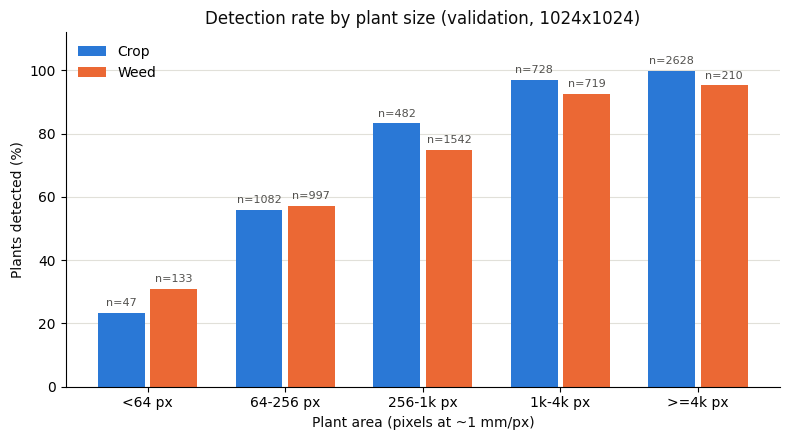

In [9]:
import matplotlib.pyplot as plt

CROP_COLOR, WEED_COLOR = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"

results["size_analysis"] = {}
for cls, name in ((1, "crop"), (2, "weed")):
    s = size_stats[cls]
    rows = []
    print(f"\n{name.upper()} plants (complete plants only; area in px, ~mm^2)")
    print(f"{'area':<9}{'plants':>8}{'detected':>10}{'pixel recall':>14}{'missed px -> soil':>19}")
    for i, label in enumerate(SIZE_LABELS):
        n = int(s["objects"][i])
        missed = s["pixels"][i] - s["correct"][i]
        row = {
            "area_px": label, "plants": n,
            "detection_rate": float(s["detected"][i] / n) if n else None,
            "pixel_recall": float(s["correct"][i] / s["pixels"][i]) if n else None,
            "missed_pixels_to_soil": float(s["to_soil"][i] / missed) if missed > 0 else None,
        }
        rows.append(row)
        if n:
            to_soil = f"{row['missed_pixels_to_soil']:.0%}" if row["missed_pixels_to_soil"] is not None else "-"
            print(f"{label:<9}{n:>8}{row['detection_rate']:>10.1%}{row['pixel_recall']:>14.1%}{to_soil:>19}")
    results["size_analysis"][name] = rows

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(SIZE_LABELS))
width = 0.38
for offset, name, color in ((-width / 2, "crop", CROP_COLOR), (width / 2, "weed", WEED_COLOR)):
    rows = results["size_analysis"][name]
    rates = [100 * r["detection_rate"] if r["plants"] else np.nan for r in rows]
    bars = ax.bar(x + offset, rates, width - 0.04, color=color, label=name.capitalize())
    for bar, r in zip(bars, rows):
        if r["plants"]:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"n={r['plants']}",
                    ha="center", va="bottom", fontsize=8, color=MUTED)
ax.set_xticks(x, [f"{l} px" for l in SIZE_LABELS])
ax.set_ylim(0, 112)
ax.set_ylabel("Plants detected (%)", color=INK)
ax.set_xlabel("Plant area (pixels at ~1 mm/px)", color=INK)
ax.set_title("Detection rate by plant size (validation, 1024x1024)", color=INK)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "detection_by_size.png", dpi=150)
plt.show()

### 4.2 Where do errors occur?

In [10]:
total_err = sum(int(v[1]) for v in zone_stats.values())
total_swap = sum(int(v[2]) for v in zone_stats.values())
total_px = sum(int(v[0]) for v in zone_stats.values())
results["error_zones"] = {"width_px": ZONE_WIDTH, "zones": {}}

print(f"{'zone':<20}{'% of pixels':>12}{'error rate':>12}{'% of all errors':>17}{'% of crop<->weed swaps':>24}")
for name in ZONES:
    pixels, errors, swaps = (int(v) for v in zone_stats[name])
    row = {
        "share_of_pixels": pixels / total_px,
        "error_rate": errors / pixels if pixels else None,
        "share_of_all_errors": errors / total_err if total_err else None,
        "share_of_crop_weed_swaps": swaps / total_swap if total_swap else None,
    }
    results["error_zones"]["zones"][name] = row
    fmt = lambda v: f"{v:.2%}" if v is not None else "-"
    print(f"{name:<20}{fmt(row['share_of_pixels']):>12}{fmt(row['error_rate']):>12}"
          f"{fmt(row['share_of_all_errors']):>17}{fmt(row['share_of_crop_weed_swaps']):>24}")
print(f"\nTotal errors: {total_err:,} px, of which crop<->weed swaps: {total_swap:,} px")

zone                 % of pixels  error rate  % of all errors  % of crop<->weed swaps
crop_weed_contact          0.06%      34.75%            3.15%                  25.87%
plant_soil_edge            6.03%       9.40%           89.77%                  47.08%
plant_interior             6.99%       0.43%            4.77%                  27.04%
soil_far                  86.92%       0.02%            2.30%                   0.00%

Total errors: 5,114,635 px, of which crop<->weed swaps: 429,777 px


### 4.3 Worst weed images (error map)

Validation images with at least 500 weed pixels, ranked by per-image weed IoU. In the error map: **pink** = plant missed (predicted soil), **yellow** = false plant on soil, **green** = crop and weed swapped.

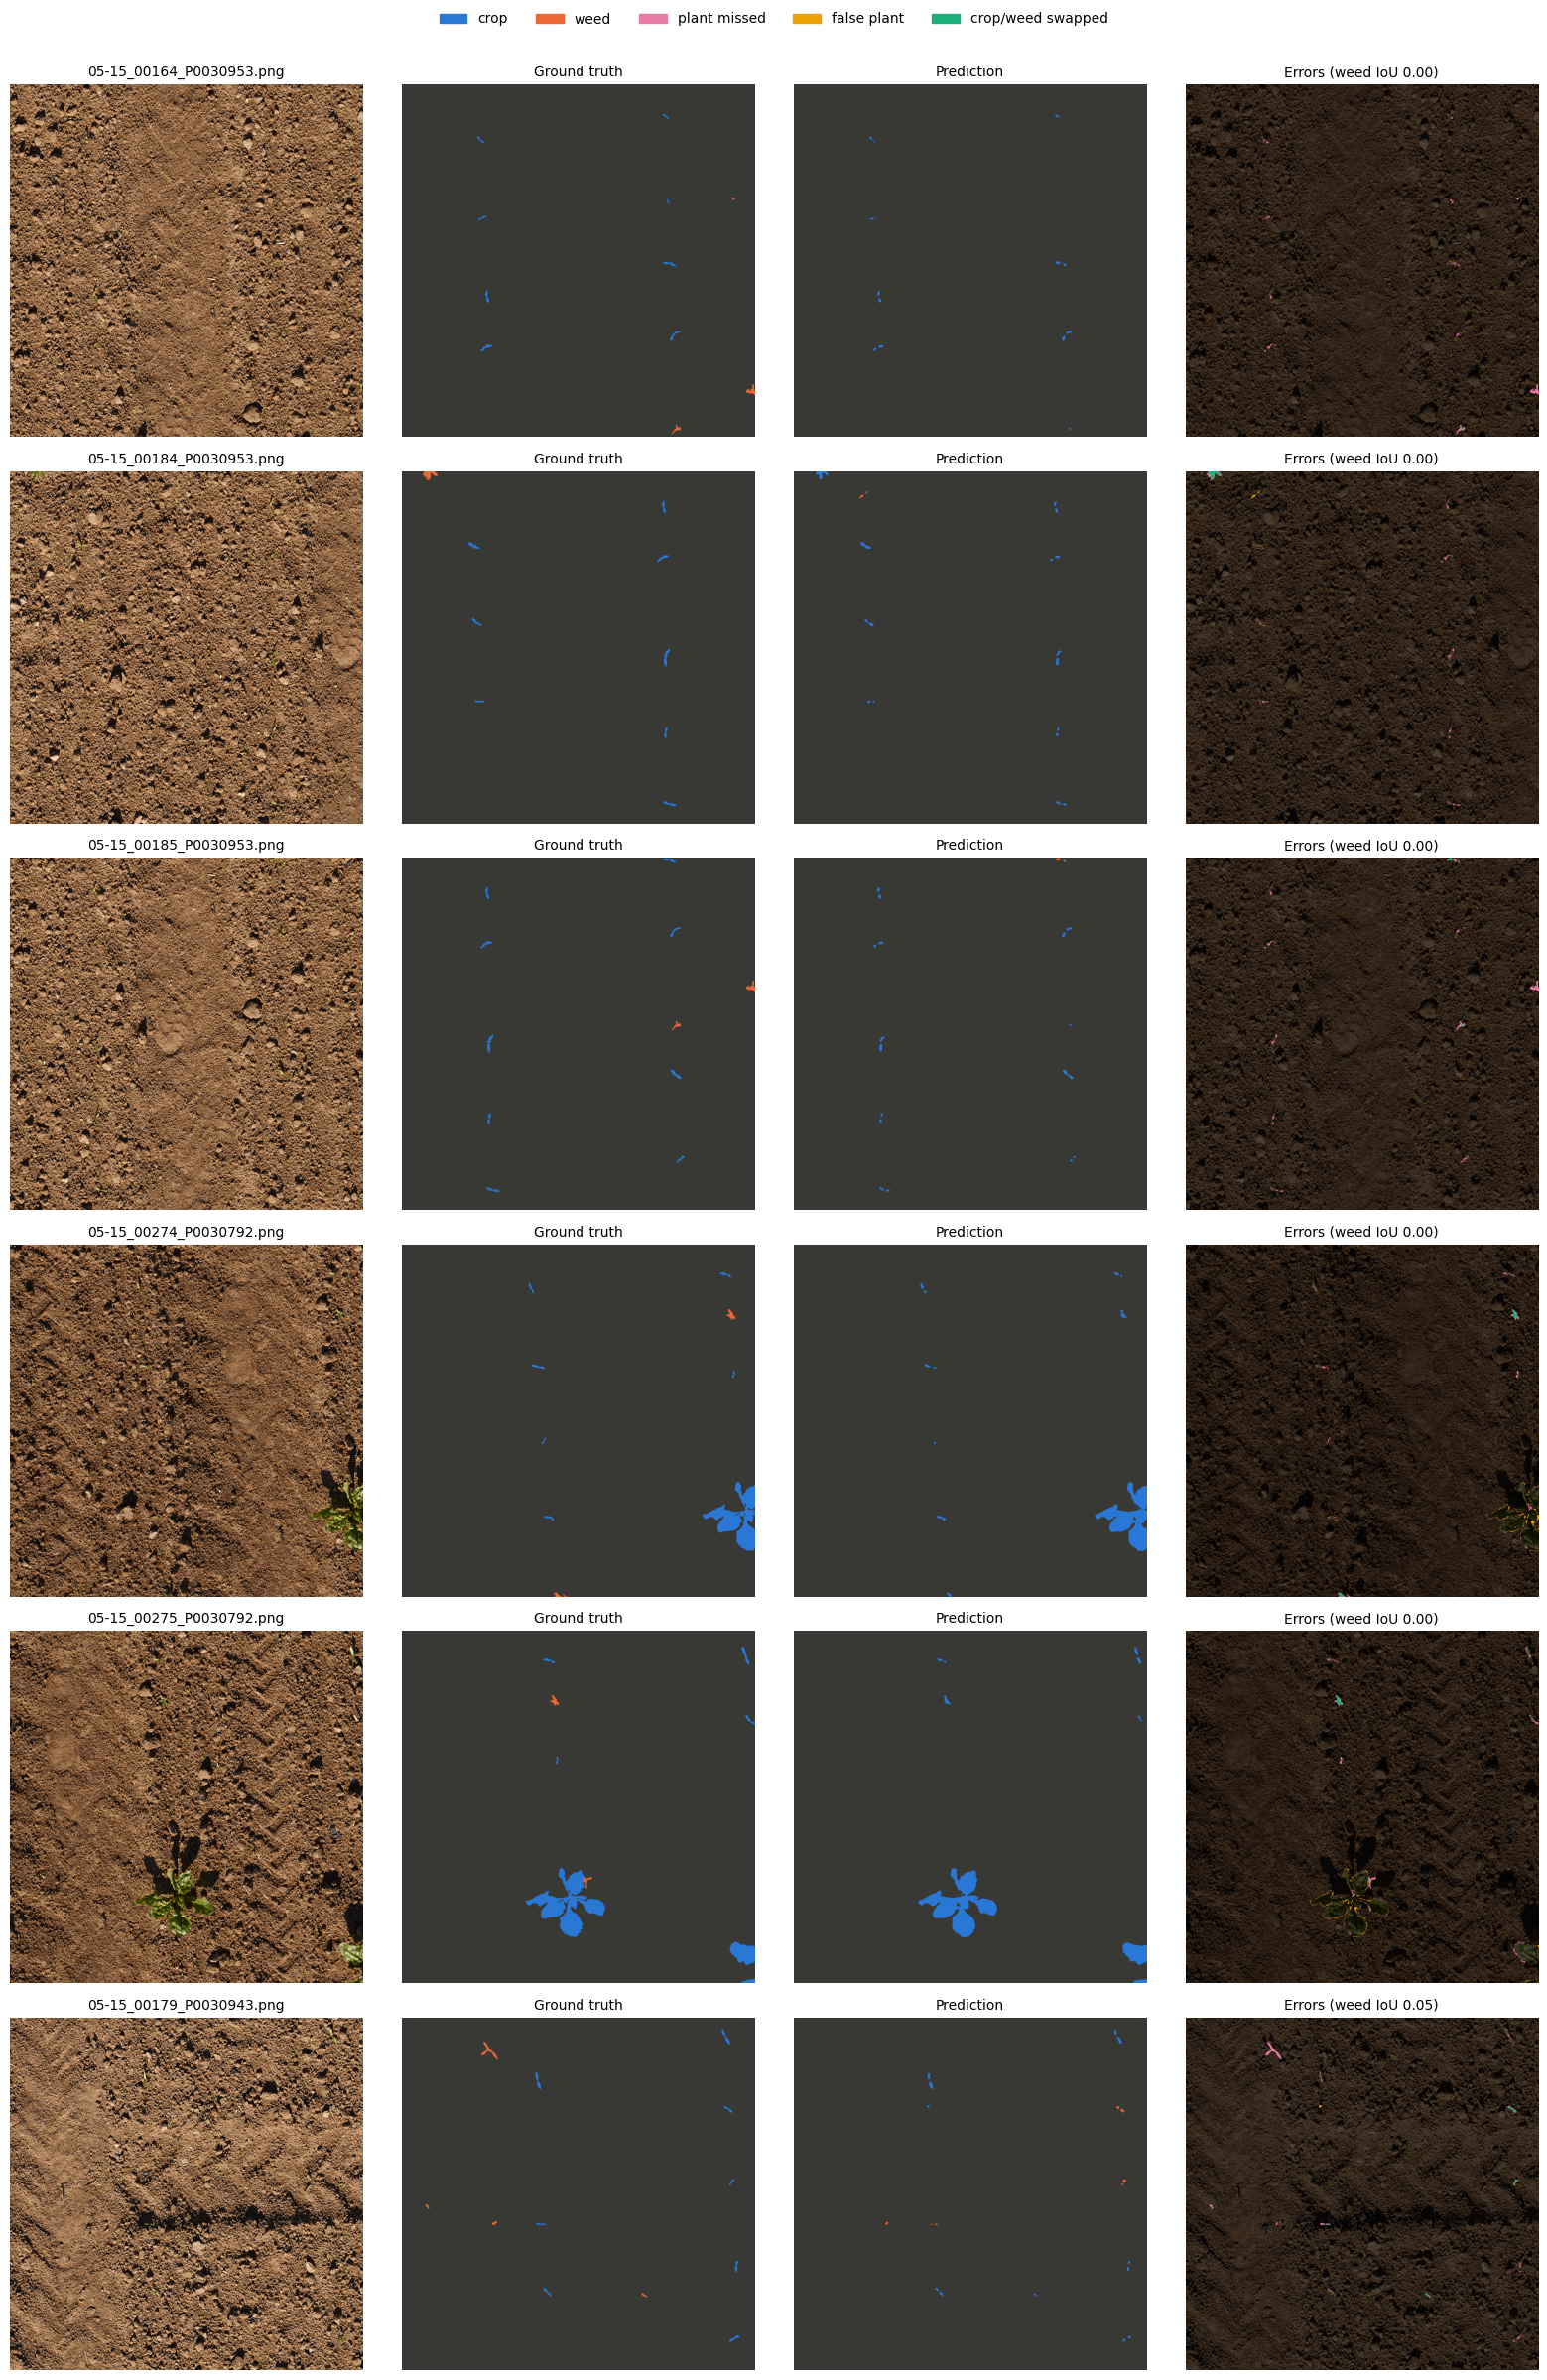

05-15_00164_P0030953.png: weed IoU 0.000
05-15_00184_P0030953.png: weed IoU 0.000
05-15_00185_P0030953.png: weed IoU 0.000
05-15_00274_P0030792.png: weed IoU 0.000
05-15_00275_P0030792.png: weed IoU 0.000
05-15_00179_P0030943.png: weed IoU 0.047


In [11]:
from matplotlib.patches import Patch

LABEL_COLORS = np.array([[56, 56, 53], [42, 120, 214], [235, 104, 52]], dtype=np.uint8)  # soil, crop, weed
MISSED, FALSE_PLANT, SWAP = (232, 123, 164), (237, 161, 0), (27, 175, 122)


def per_image_weed_iou(cm):
    denom = cm[2, :].sum() + cm[:, 2].sum() - cm[2, 2]
    return cm[2, 2] / denom if denom else np.nan


candidates = [(name, per_image_weed_iou(cm)) for name, cm in per_image if cm[2, :].sum() >= 500]
worst = sorted(candidates, key=lambda t: t[1])[:6]
results["worst_weed_images"] = [{"image": n, "weed_iou": float(v)} for n, v in worst]

assert worst, "No validation image has >= 500 weed pixels"
fig, axes = plt.subplots(len(worst), 4, figsize=(16, 4 * len(worst)), squeeze=False)
for row, (name, weed_iou) in enumerate(worst):
    path = PHENOBENCH_DIR / "val" / "images" / name
    image = read_rgb(path)
    gt = MERGE[read_label(path, "semantics")]
    pred = cv2.imread(str(VAL_PRED_DIR / name), cv2.IMREAD_UNCHANGED)
    error_map = (image * 0.35).astype(np.uint8)
    error_map[(gt > 0) & (pred == 0)] = MISSED
    error_map[(gt == 0) & (pred > 0)] = FALSE_PLANT
    error_map[(gt > 0) & (pred > 0) & (gt != pred)] = SWAP
    panels = [(image, name), (LABEL_COLORS[gt], "Ground truth"),
              (LABEL_COLORS[pred], "Prediction"), (error_map, f"Errors (weed IoU {weed_iou:.2f})")]
    for col, (img, title) in enumerate(panels):
        axes[row, col].imshow(img)
        axes[row, col].set_title(title, fontsize=10)
        axes[row, col].axis("off")
legend = [Patch(color=np.array(c) / 255, label=l) for c, l in
          ((LABEL_COLORS[1], "crop"), (LABEL_COLORS[2], "weed"), (MISSED, "plant missed"),
           (FALSE_PLANT, "false plant"), (SWAP, "crop/weed swapped"))]
fig.legend(handles=legend, loc="upper center", ncol=5, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.savefig(OUTPUT_DIR / "worst_weed_images.png", dpi=100)
plt.show()
for name, v in worst:
    print(f"{name}: weed IoU {v:.3f}")

## 5. Test-set submission file

Predicts all 693 test images at 1024×1024 (same method as the validation 1024 row), writes them as `semantics/<image name>.png` with values 0 = soil, 1 = crop, 2 = weed, zips them, and runs PhenoBench's official validator on the zip. The zip is copied to `MyDrive/CropSeg/evaluation/submission.zip`.

In [12]:
import os
import shutil
import subprocess
import sys
import zipfile

TEST_PRED_DIR = WORK_DIR / "submission" / "semantics"
TEST_PRED_DIR.mkdir(parents=True, exist_ok=True)

for path in tqdm(test_images, desc="test"):
    _, _, pred_full = run_model(read_rgb(path))
    cv2.imwrite(str(TEST_PRED_DIR / path.name), pred_full)

zip_path = WORK_DIR / "submission.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.writestr(zipfile.ZipInfo("semantics/"), "")  # the validator requires this folder entry
    for p in sorted(TEST_PRED_DIR.glob("*.png")):
        zf.write(p, f"semantics/{p.name}")

check = subprocess.run([sys.executable, "-m", "phenobench.tools.validator", "--task", "semantics",
                        "--phenobench_dir", str(PHENOBENCH_DIR), "--zipfile", str(zip_path)],
                       capture_output=True, text=True, encoding="utf-8",
                       env={**os.environ, "PYTHONIOENCODING": "utf-8"})
print(check.stdout, check.stderr)
results["test_submission"] = {"images": len(test_images), "validator_passed": check.returncode == 0}

shutil.copy(zip_path, OUTPUT_DIR / "submission.zip")
print(f"Saved {OUTPUT_DIR / 'submission.zip'} ({zip_path.stat().st_size / 1e6:.1f} MB)")

test:   0%|          | 0/693 [00:00<?, ?it/s]

Validating zip archive "/content/cropseg_eval/submission.zip".

 ==========    semantics    ========== 
  1. Checking filename.............. ✓
  2. Checking directory structure... ✓
  3. Checking files................. ✓

Everything ready for submission!  🎉
 
Saved /content/drive/MyDrive/CropSeg/evaluation/submission.zip (5.9 MB)


## 6. Summary

Saves all numbers to `MyDrive/CropSeg/evaluation/eval_results.json` and prints a compact summary.

In [13]:
with open(OUTPUT_DIR / "eval_results.json", "w") as f:
    json.dump(results, f, indent=2)

pct = lambda v, d=1: f"{100 * v:.{d}f}%" if v is not None else "-"
print("===== SUMMARY =====")
for key in ("val_512", "val_1024"):
    r = results[key]
    print(f"{key}: mIoU {r['miou']:.4f} | soil {r['iou_soil']:.4f} | crop {r['iou_crop']:.4f} | weed {r['iou_weed']:.4f}")
print("official val (1024):", results.get("val_1024_official"))
for date, r in results["per_date_1024"].items():
    print(f"date {date}: mIoU {r['miou']:.4f} | weed {r['iou_weed']:.4f} ({r['images']} images)")
for name in ("crop", "weed"):
    rates = [f"{r['area_px']}: {pct(r['detection_rate'], 0)} (n={r['plants']})"
             for r in results["size_analysis"][name] if r["plants"]]
    print(f"{name} detection by size: " + ", ".join(rates))
for name, r in results["error_zones"]["zones"].items():
    print(f"zone {name}: {pct(r['share_of_pixels'], 2)} of pixels, {pct(r['share_of_all_errors'])} of errors, "
          f"{pct(r['share_of_crop_weed_swaps'])} of crop/weed swaps")
print("test submission:", results["test_submission"])
print(f"Saved to {OUTPUT_DIR}")

===== SUMMARY =====
val_512: mIoU 0.8714 | soil 0.9926 | crop 0.9414 | weed 0.6803
val_1024: mIoU 0.8808 | soil 0.9936 | crop 0.9487 | weed 0.7000
official val (1024): {'soil': 99.36, 'crop': 94.87, 'weed': 70.0, 'mIoU': 88.08}
date 05-15: mIoU 0.7960 | weed 0.4850 (399 images)
date 05-26: mIoU 0.8355 | weed 0.5780 (170 images)
date 06-05: mIoU 0.9070 | weed 0.7679 (203 images)
crop detection by size: <64: 23% (n=47), 64-256: 56% (n=1082), 256-1k: 83% (n=482), 1k-4k: 97% (n=728), >=4k: 100% (n=2628)
weed detection by size: <64: 31% (n=133), 64-256: 57% (n=997), 256-1k: 75% (n=1542), 1k-4k: 92% (n=719), >=4k: 95% (n=210)
zone crop_weed_contact: 0.06% of pixels, 3.2% of errors, 25.9% of crop/weed swaps
zone plant_soil_edge: 6.03% of pixels, 89.8% of errors, 47.1% of crop/weed swaps
zone plant_interior: 6.99% of pixels, 4.8% of errors, 27.0% of crop/weed swaps
zone soil_far: 86.92% of pixels, 2.3% of errors, 0.0% of crop/weed swaps
test submission: {'images': 693, 'validator_passed': True

In [14]:
# Optional: download the submission zip to your computer
from google.colab import files
files.download(str(OUTPUT_DIR / "submission.zip"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>